# Task 1 Dataset Exploration
Load the Iris dataset and answer the following:

How many samples and features are present in the dataset?

List the feature names and target classes.

Display the first five records.

Display the class distribution.


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()


num_samples, num_features = iris.data.shape
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}\n")

print(f"Feature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}\n")


iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target_names'] = iris.target_names[iris.target]
print("First five records:")
print(iris_df.head())
print("\n")

# Display the class distribution.
print("Class distribution:")
print(iris_df['target_names'].value_counts())

Number of samples: 150
Number of features: 4

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']

First five records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  


Class distribution:
target_names
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


# Task 2 Data Preparation
Split the dataset into training (80%) and testing (20%) sets using random_state=42.

Briefly explain why the dataset is divided into training and testing sets.


In [ ]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


# Task 3 Building a Decision Tree Classifier

Train a Decision Tree classifier using the default parameters.

Predict the class labels for the test dataset.

Evaluate the model using:

Accuracy Score

Confusion Matrix

Classification Report


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using the default parameters.
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# Predict the class labels for the test dataset.
y_pred = dtc.predict(X_test)

# Evaluate the model using:

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print("\n")

# Classification Report
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("Classification Report:")
print(class_report)

Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



The Decision Tree classifier achieved 100% accuracy on the test dataset
The confusion matrix shows no misclassified samples

Precision, Recall and F1-score are all 1.00 for every class

The Iris dataset is easily separable allowing the Decision Tree to classify every flower correctly

# Task 4: Visualizing the Decision Tree

Visualize the trained Decision Tree using plot_tree().

From the visualization, identify:

Root node

Internal nodes

Leaf nodes

Maximum depth of the tree


Which feature is selected for the first split? Explain why you think this feature was chosen.


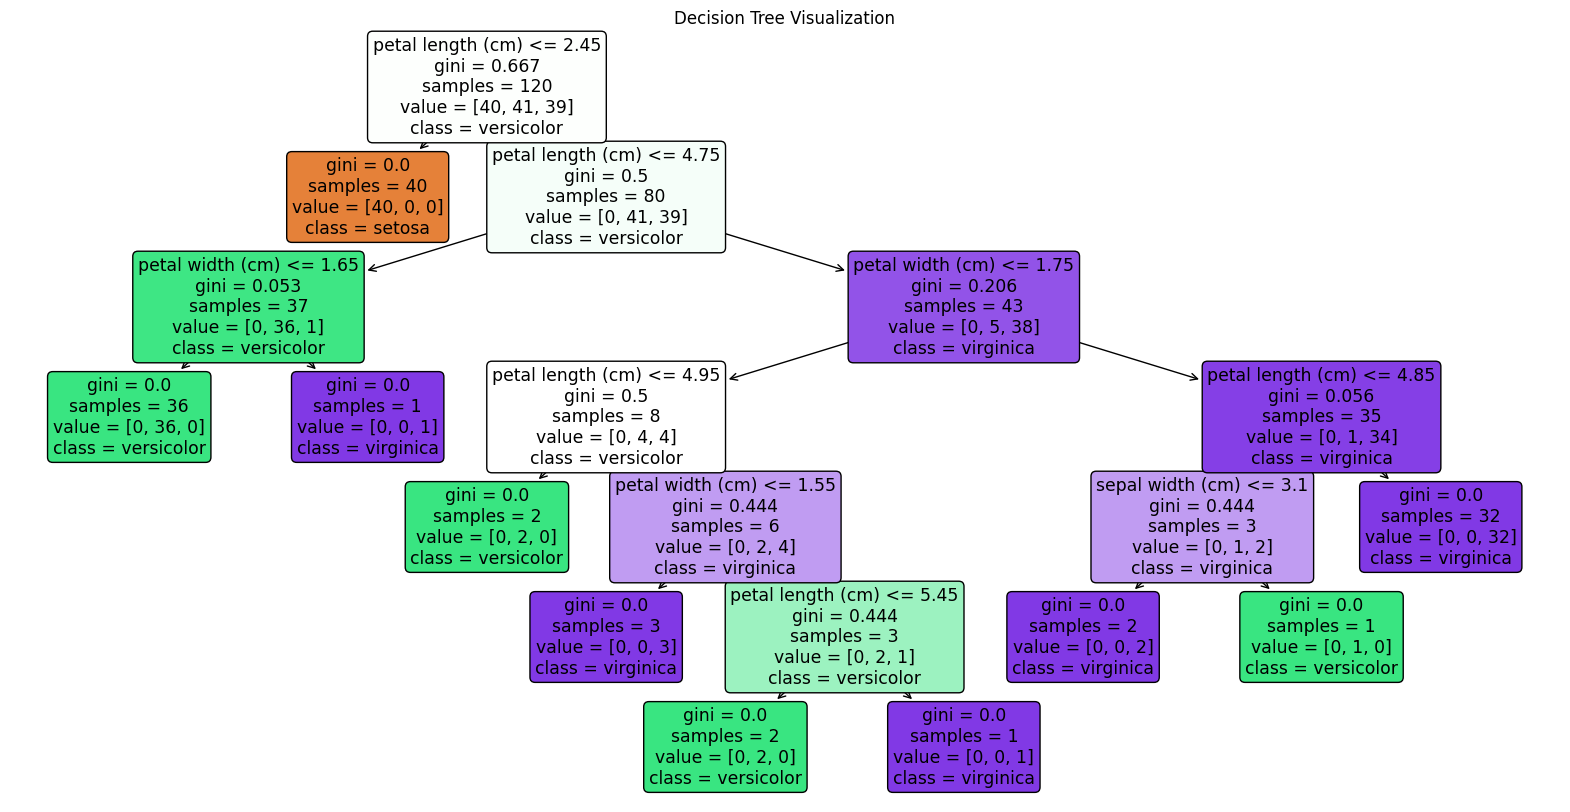


Maximum depth of the tree: 6



In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Visualize the trained Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dtc, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# Identify maximum depth
max_depth = dtc.get_depth()
print(f"\nMaximum depth of the tree: {max_depth}\n")


The Decision Tree selected Petal Length because it provides the highest information gain

# Task 5: Comparing Gini Index and Entropy

Train two Decision Tree models using the following criteria:

criterion='gini'
criterion='entropy'

Compare the models based on:

Accuracy

Tree depth

Number of leaf nodes

Root feature selected

Which criterion produces a simpler tree?


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- Model 1: Gini Criterion ---
print("\nModel with Gini Criterion")
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)
y_pred_gini = dtc_gini.predict(X_test)

accuracy_gini = accuracy_score(y_test, y_pred_gini)
tree_depth_gini = dtc_gini.get_depth()
leaf_nodes_gini = dtc_gini.get_n_leaves()
root_feature_gini_idx = dtc_gini.tree_.feature[0]
root_feature_gini = iris.feature_names[root_feature_gini_idx]

print(f"Accuracy: {accuracy_gini:.4f}")
print(f"Tree Depth: {tree_depth_gini}")
print(f"Number of Leaf Nodes: {leaf_nodes_gini}")
print(f"Root Feature Selected: {root_feature_gini}")

# --- Model 2: Entropy Criterion ---
print("\n Model with Entropy Criterion")
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)
y_pred_entropy = dtc_entropy.predict(X_test)

accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
tree_depth_entropy = dtc_entropy.get_depth()
leaf_nodes_entropy = dtc_entropy.get_n_leaves()
root_feature_entropy_idx = dtc_entropy.tree_.feature[0]
root_feature_entropy = iris.feature_names[root_feature_entropy_idx]

print(f"Accuracy: {accuracy_entropy:.4f}")
print(f"Tree Depth: {tree_depth_entropy}")
print(f"Number of Leaf Nodes: {leaf_nodes_entropy}")
print(f"Root Feature Selected: {root_feature_entropy}")

# --- Comparison Summary ---
print("\n Comparison Summary")
print(" Metric                   Gini      Entropy   ")
print(f" Accuracy Score           {accuracy_gini:.4f}   {accuracy_entropy:.4f} ")
print(f" Tree Depth               {tree_depth_gini:<9}  {tree_depth_entropy:<9} ")
print(f" Number of Leaf Nodes     {leaf_nodes_gini:<9} {leaf_nodes_entropy:<9} ")
print(f" Root Feature Selected    {root_feature_gini[:7]}  {root_feature_entropy[:7]} ")




Model with Gini Criterion
Accuracy: 1.0000
Tree Depth: 6
Number of Leaf Nodes: 10
Root Feature Selected: petal length (cm)

 Model with Entropy Criterion
Accuracy: 1.0000
Tree Depth: 6
Number of Leaf Nodes: 10
Root Feature Selected: petal length (cm)

 Comparison Summary
 Metric                   Gini      Entropy   
 Accuracy Score           1.0000   1.0000 
 Tree Depth               6          6         
 Number of Leaf Nodes     10        10        
 Root Feature Selected    petal l  petal l 


Both Gini Index and Entropy achieved 100% testing accuracy

Both selected Petal Length as the root node

Both generated trees with the same depth and number of leaf nodes

No significant difference exists between Gini and Entropy for the Iris dataset

# Task 6: Effect of Maximum Tree Depth
Train Decision Tree models using the following values of max_depth:

1

2

3

4

None


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

max_depth_values = [1, 2, 3, 4, None]
results = []

print("Evaluating Decision Tree models with different max_depth values:\n")

for depth in max_depth_values:
    print(f"Training model with max_depth={depth}")
    dtc = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtc.fit(X_train, y_train)

    # Training Accuracy
    y_train_pred = dtc.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Testing Accuracy
    y_test_pred = dtc.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Tree Depth
    tree_depth = dtc.get_depth()

    results.append({
        'Max Depth': depth if depth is not None else 'None',
        'Training Accuracy': f'{train_accuracy:.4f}',
        'Testing Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Observation': ''
    })

# Display results in a DataFrame for better readability
results_df = pd.DataFrame(results)
print("\nDecision Tree Performance by Max Depth:")
print(results_df.to_string(index=False))

Evaluating Decision Tree models with different max_depth values:

Training model with max_depth=1
Training model with max_depth=2
Training model with max_depth=3
Training model with max_depth=4
Training model with max_depth=None

Decision Tree Performance by Max Depth:
Max Depth Training Accuracy Testing Accuracy  Tree Depth Observation
        1            0.6750           0.6333           1            
        2            0.9500           0.9667           2            
        3            0.9583           1.0000           3            
        4            0.9750           1.0000           4            
     None            1.0000           1.0000           6            


#Which model is underfitting?

max_depth = 1

The tree is too shallow and cannot learn the underlying patterns

# Which model gives the best generalization?

max_depth = 3

Achieves 100% testing accuracy
Uses a smaller tree than the unrestricted model
Balances simplicity and predictive performance
#Which model is likely to overfit?

max_depth = None

The tree  memorizes the training data tree is more likely to overfit when applied to larger datasets

#Task 7: Effect of min_samples_split
Train Decision Tree models using:

2

5

10

20


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

min_samples_split_values = [2, 5, 10, 20]
results_min_samples_split = []

print("Evaluating Decision Tree models with different min_samples_split values:\n")

for mss in min_samples_split_values:
    print(f"Training model with min_samples_split={mss}")
    dtc = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    dtc.fit(X_train, y_train)

    # Testing Accuracy
    y_test_pred = dtc.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Tree Depth
    tree_depth = dtc.get_depth()

    # Number of Leaf Nodes
    num_leaf_nodes = dtc.get_n_leaves()

    results_min_samples_split.append({
        'min_samples_split': mss,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': ''
    })

# Display results in a DataFrame for better readability
results_df_mss = pd.DataFrame(results_min_samples_split)
print("\nDecision Tree Performance by min_samples_split:")
print(results_df_mss.to_string(index=False))

Evaluating Decision Tree models with different min_samples_split values:

Training model with min_samples_split=2
Training model with min_samples_split=5
Training model with min_samples_split=10
Training model with min_samples_split=20

Decision Tree Performance by min_samples_split:
 min_samples_split Accuracy  Tree Depth  Number of Leaf Nodes Observation
                 2   1.0000           6                    10            
                 5   1.0000           5                     8            
                10   1.0000           4                     6            
                20   1.0000           4                     6            


Increasing min_samples_split reduces unnecessary splits

decreases tree depth decreases the number of leaf nodes

creates a simpler and more generalized model helps reduce overfitting without affecting the  aacuracy

#Task 8: Effect of min_samples_leaf
Train Decision Tree models using:

1

2

5

10

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

min_samples_leaf_values = [1, 2, 5, 10]
results_min_samples_leaf = []

print("Evaluating Decision Tree models with different min_samples_leaf values:\n")

for msl in min_samples_leaf_values:
    print(f"Training model with min_samples_leaf={msl}")
    dtc = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    dtc.fit(X_train, y_train)

    # Testing Accuracy
    y_test_pred = dtc.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Tree Depth
    tree_depth = dtc.get_depth()

    # Number of Leaf Nodes
    num_leaf_nodes = dtc.get_n_leaves()

    results_min_samples_leaf.append({
        'min_samples_leaf': msl,
        'Accuracy': f'{test_accuracy:.4f}',
        'Tree Depth': tree_depth,
        'Number of Leaf Nodes': num_leaf_nodes,
        'Observation': ''
    })

# Display results in a DataFrame for better readability
results_df_msl = pd.DataFrame(results_min_samples_leaf)
print("\nDecision Tree Performance by min_samples_leaf:")
print(results_df_msl.to_string(index=False))

Evaluating Decision Tree models with different min_samples_leaf values:

Training model with min_samples_leaf=1
Training model with min_samples_leaf=2
Training model with min_samples_leaf=5
Training model with min_samples_leaf=10

Decision Tree Performance by min_samples_leaf:
 min_samples_leaf Accuracy  Tree Depth  Number of Leaf Nodes Observation
                1   1.0000           6                    10            
                2   1.0000           5                     8            
                5   1.0000           4                     6            
               10   0.9667           4                     6            


increasing min_samples_leaf prevents the model from learning tiny variations in the training data resulting in a simpler tree with better generalization

#Task 9: Hyperparameter Tuning
Perform hyperparameter tuning using GridSearchCV with the following parameters:

criterion: gini, entropy

max_depth: 2, 3, 4, None

min_samples_split: 2, 5, 10


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Define the parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='accuracy' to evaluate models based on accuracy
# verbose=1 to see progress
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

print("Performing GridSearchCV...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("\nGridSearchCV complete!")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters found: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

# Display all results in a DataFrame
results_gs = pd.DataFrame(grid_search.cv_results_)
results_gs = results_gs.sort_values(by='mean_test_score', ascending=False)

print("\nAll GridSearchCV results (top 10):")
print(results_gs[['param_criterion', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'rank_test_score']].head(10).to_string(index=False))


Performing GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

GridSearchCV complete!

Best parameters found: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}
Best cross-validation accuracy: 0.9417

All GridSearchCV results (top 10):
param_criterion param_max_depth  param_min_samples_split  mean_test_score  rank_test_score
           gini               4                        2         0.941667                1
           gini            None                        2         0.941667                1
        entropy            None                        2         0.941667                1
           gini               3                        2         0.933333                4
           gini               4                        5         0.933333                4
           gini            None                       10         0.933333                4
           gini               3                        5         0.933333                

The optimized model achieves the same testing accuracy as the default model while using a shallower tree it reduces model complexity and improves generalization

#1. What is the role of the criterion parameter?

The criterion determines how the Decision Tree measures the quality of a split

It chooses the feature that best separates the classes by minimizing impurity

Common criteria are Gini Index and Entropy

#2. How does max_depth influence underfitting and overfitting?
Small values of max_depth produce shallow trees that may underfit because they cannot learn enough patterns

Large values allow the tree to grow deeper increasing its ability to fit the training data but also increasing the risk of overfitting

An appropriate depth balances model complexity and generalization
#3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

Larger values require more samples before a split or leaf can be created this prevents unnecessary branching resulting in fewer nodes lower depth and improved generalization

#4. Which hyperparameter had the greatest impact?

Among all hyperparameters  max_depth had the greatest impact

Accuracy increased from 63.33% at depth 1 to 100% at depth 3
Tree complexity increased steadily with depth

Other parameters mainly reduced tree complexity while maintaining nearly the same accuracy

max_depth most strongly influenced both learning capability and model performance

#5. Recommend the most suitable Decision Tree model.

The most suitable model for the Iris dataset is the Decision Tree with:

criterion = gini
max_depth = 4
min_samples_split = 2

This model achieves 100% testing accuracy while maintaining a simpler tree than the default model it balances prediction performance model complexity and generalization making it the best overall choice for the Iris classification problem